# Single-Heralded Network Examples

This notebook collects the reference SeQUeNCe examples used to understand time-dependent fidelity, swap timing, and continuous-operation behavior in single-heralded links. It is kept next to the queueing model notebook because both workflows share the same physical assumptions and helper layer.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


def find_repo_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / 'sequence').exists() and (candidate / 'example' / 'queueing_model').exists():
            return candidate
    raise RuntimeError(f'Could not find SeQUeNCe repo root from {start}')


REPO_ROOT = find_repo_root(Path.cwd())
QUEUEING_DIR = REPO_ROOT / 'example' / 'queueing_model'
CORE_EXPERIMENT_DIR = REPO_ROOT / 'example' / 'entanglement_distribution_experiment'
for path in (REPO_ROOT, QUEUEING_DIR, CORE_EXPERIMENT_DIR):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from eg_single_heralded_helpers import (
    ElementaryLinkConfig,
    SwapCalibration,
    collect_three_node_swap_time_trace,
    collect_two_node_decay_trace,
    collect_three_node_rate_over_time,
    collect_three_node_swap_waiting_histogram,
    FixedGeneratedLifetimePolicy,
    run_two_node_continuous_experiment,
    run_three_node_continuous_experiment,
    sweep_three_node_cutoff_ratio_continuous,
    sweep_three_node_target_fidelity_continuous,
)
from memory_allocation_queue_sim import (
    AllocationQueueConfig,
    reference_ttls_for_required_fidelity,
    run_memory_allocation_sequence_trial,
)
from sequence.components.fiber_quantum_channel import FiberSpec


## Two-Node Fidelity Decay In Time

This section shows the same successful two-node sample in two views. The left panel is the stock memory-level fidelity snapshot, and the right panel is the shared pair fidelity read from the Bell-diagonal state in the quantum manager.


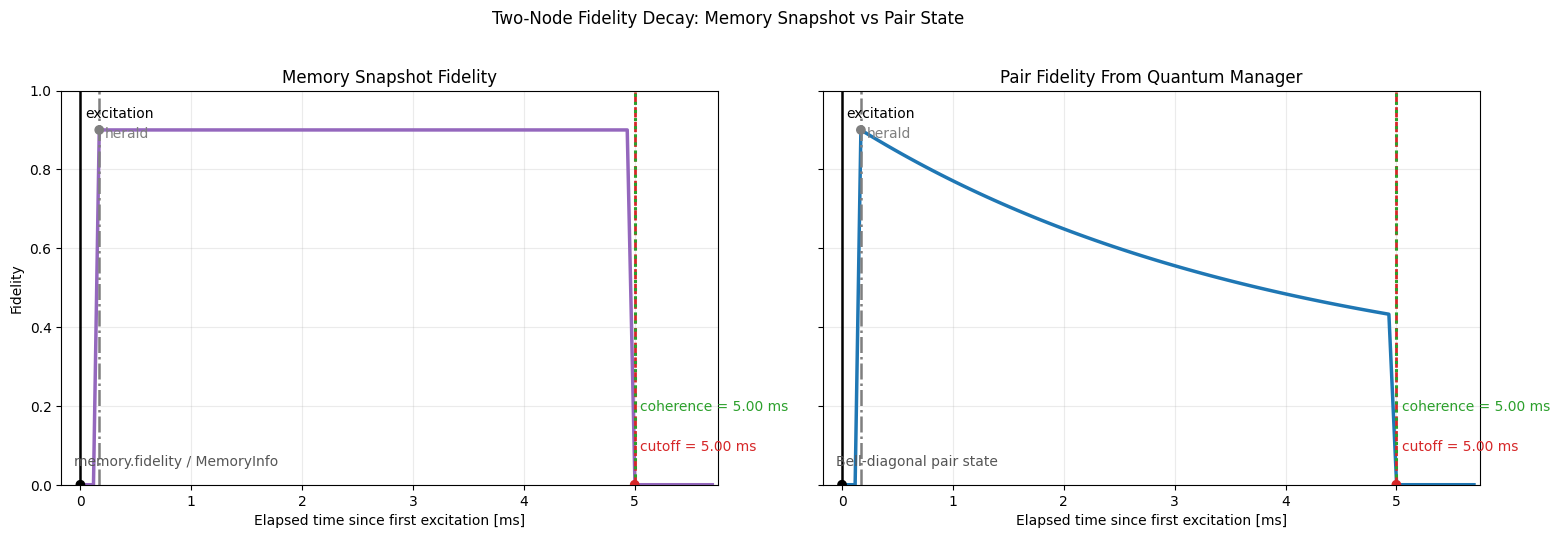

{'seed_used': 321,
 'tries_used': 1,
 'herald_time_ms': 0.17000000999999998,
 'cutoff_time_ms': 5.0,
 'coherence_time_ms': 5.0}

In [5]:
base_spec = FiberSpec(
    wavelength_m=1550e-9,
    quantum_wavelength_nm=1550.0,
)

decay_link = ElementaryLinkConfig(
    label="two-node decay trace",
    distance_m=32_000,
    attenuation_db_per_m=0.0002,
    coherence_time_s=0.005,
    cutoff_ratio=1.0,
    bsm_success_rate=0.9,
    raw_fidelity=0.9,
    raw_epr_errors=[1/3, 1/3, 1/3],
    detector_efficiency=0.95,
    detector_count_rate=5e7,
    detector_resolution_ps=150,
    fiber_spec=base_spec,
)

decay_trace = collect_two_node_decay_trace(
    decay_link,
    seed=321,
    generation_window_s=0.05,
    sample_points=80,
    horizon_factor=1.15,
    max_seed_tries=40,
)

if not decay_trace["success"]:
    raise RuntimeError("No successful two-node pair was found for the decay plot.")

times_ms = np.array(decay_trace["elapsed_times_s"]) * 1e3
memory_fidelities = np.array(decay_trace["memory_fidelities"])
pair_fidelities = np.array(decay_trace["fidelities"])
excitation_ms = 0.0
herald_ms = (decay_trace["entangle_time_s"] - decay_trace["memory_start_time_s"]) * 1e3
cutoff_ms = decay_trace["cutoff_time_s"] * 1e3
coherence_ms = decay_trace["coherence_time_s"] * 1e3
xmax_ms = max(times_ms.max(), coherence_ms * 1.15)
xmin_ms = -0.03 * xmax_ms

fig, axes = plt.subplots(1, 2, figsize=(15.5, 5.4), sharex=True, sharey=True)

plot_specs = [
    (axes[0], memory_fidelities, "#9467bd", "Memory Snapshot Fidelity", "memory.fidelity / MemoryInfo"),
    (axes[1], pair_fidelities, "#1f77b4", "Pair Fidelity From Quantum Manager", "Bell-diagonal pair state"),
]

for ax, trace, color, title, subtitle in plot_specs:
    ax.plot(times_ms, trace, color=color, linewidth=2.5)
    ax.axvline(excitation_ms, color="#000000", linestyle="-", linewidth=1.8)
    ax.axvline(herald_ms, color="#7f7f7f", linestyle="-.", linewidth=1.8)
    ax.axvline(cutoff_ms, color="#d62728", linestyle="--", linewidth=2)
    ax.axvline(coherence_ms, color="#2ca02c", linestyle=":", linewidth=2.2)
    ax.scatter([excitation_ms, herald_ms, cutoff_ms], [float(np.interp(excitation_ms, times_ms, trace)), float(np.interp(herald_ms, times_ms, trace)), 0.0], color=["#000000", "#7f7f7f", "#d62728"], zorder=3)
    ax.set_xlim(xmin_ms, xmax_ms)
    ax.set_ylim(0, 1.0)
    ax.set_title(title)
    ax.text(0.02, 0.04, subtitle, transform=ax.transAxes, color="#555555", ha="left", va="bottom")
    ax.set_xlabel("Elapsed time since first excitation [ms]")
    ax.grid(alpha=0.25)
    ax.text(max(xmin_ms + 0.1, 0.04), 0.96, "excitation", color="#000000", ha="left", va="top")
    ax.text(herald_ms + 0.05, 0.88, "herald", color="#7f7f7f", ha="left")
    ax.text(cutoff_ms + 0.05, 0.08, f"cutoff = {cutoff_ms:.2f} ms", color="#d62728", ha="left", va="bottom")
    ax.text(coherence_ms + 0.05, 0.18, f"coherence = {coherence_ms:.2f} ms", color="#2ca02c", ha="left", va="bottom")

axes[0].set_ylabel("Fidelity")
fig.suptitle("Two-Node Fidelity Decay: Memory Snapshot vs Pair State", y=1.02)
fig.subplots_adjust(left=0.07, right=0.985, bottom=0.14, top=0.87, wspace=0.16)
plt.show()

{
    "seed_used": decay_trace["seed_used"],
    "tries_used": decay_trace["tries_used"],
    "herald_time_ms": herald_ms,
    "cutoff_time_ms": cutoff_ms,
    "coherence_time_ms": coherence_ms,
}


## Stock Reported Fidelity vs Pair-State Fidelity

This section compares two different questions. For two nodes, it compares the stock reported memory snapshot against the pair-state fidelity read from the quantum manager. For three nodes, it compares a true stock swapping run against the fidelity-aware swapping extension on the same topology and request.


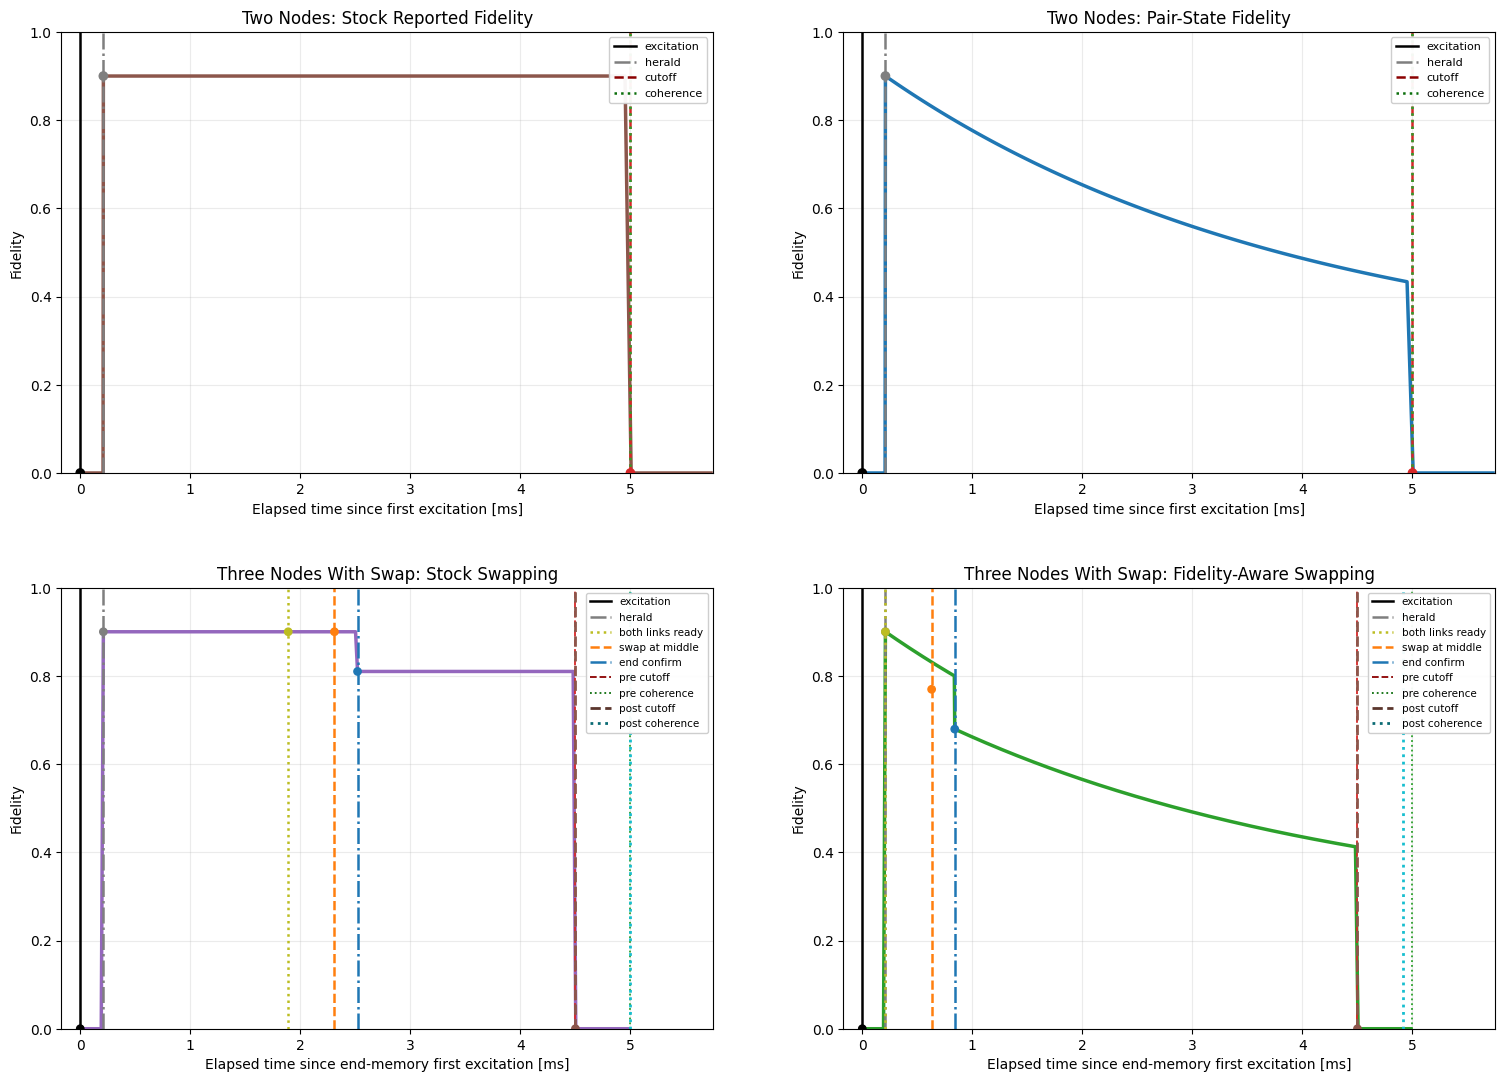

Two-node comparison log
  Stock reported path: entanglement heralded at 0.210 ms; reported fidelity set to raw fidelity 0.900000.
  Pair-state path: entanglement heralded at 0.210 ms; quantum-manager pair fidelity at herald = 0.900000.

Three-node stock swapping log
  Elementary entanglement heralded for tracked end memory at 0.210 ms; tracked reported fidelity = 0.900000.
  Both elementary links were ready at 1.890 ms.
  Middle-node swap executed at 2.310 ms; stock swap used left fidelity 0.900000, right fidelity 0.900000, result fidelity 0.810000.
  End node confirmed the swapped pair at 2.520 ms; end-to-end reported fidelity = 0.810000.
  Protocol-pairing/control delay between both-links-ready and middle-node swap = 0.420 ms.

Three-node fidelity-aware swapping log
  Elementary entanglement heralded for tracked end memory at 0.210 ms; tracked pair-state fidelity at herald = 0.900000.
  Both elementary links were ready at 0.210 ms.
  Middle-node swap executed at 0.630 ms; fidelity-aw

In [6]:
comparison_decay_link = ElementaryLinkConfig(
    label="comparison decay trace",
    distance_m=40_000,
    attenuation_db_per_m=0.0002,
    coherence_time_s=0.005,
    cutoff_ratio=1,
    bsm_success_rate=0.9,
    raw_fidelity=0.9,
    raw_epr_errors=[1/3, 1/3, 1/3],
    detector_efficiency=0.95,
    detector_count_rate=5e7,
    detector_resolution_ps=150,
    fiber_spec=base_spec,
)

comparison_decay_trace = collect_two_node_decay_trace(
    comparison_decay_link,
    seed=321,
    generation_window_s=0.05,
    sample_points=100,
    horizon_factor=1.15,
    max_seed_tries=40,
)

if not comparison_decay_trace["success"]:
    raise RuntimeError("No successful two-node decay sample was found for the comparison panel.")

comparison_times_ms = np.array(comparison_decay_trace["elapsed_times_s"]) * 1e3
comparison_fidelities = np.array(comparison_decay_trace["fidelities"])
comparison_herald_ms = (comparison_decay_trace["entangle_time_s"] - comparison_decay_trace["memory_start_time_s"]) * 1e3
comparison_cutoff_ms = comparison_decay_trace["cutoff_time_s"] * 1e3
comparison_coherence_ms = comparison_decay_trace["coherence_time_s"] * 1e3

two_node_before_times_ms = comparison_times_ms
two_node_before_fidelity = np.zeros_like(two_node_before_times_ms, dtype=float)
two_node_before_fidelity[two_node_before_times_ms >= comparison_herald_ms] = comparison_decay_link.raw_fidelity
two_node_before_fidelity[two_node_before_times_ms >= comparison_cutoff_ms] = 0.0

comparison_left = ElementaryLinkConfig(
    label="comparison left",
    distance_m=40_000,
    attenuation_db_per_m=0.0002,
    coherence_time_s=0.005,
    cutoff_ratio=0.9,
    bsm_success_rate=0.9,
    raw_fidelity=0.9,
    raw_epr_errors=[1/3, 1/3, 1/3],
    detector_efficiency=0.95,
    detector_count_rate=5e7,
    detector_resolution_ps=150,
    fiber_spec=base_spec,
)

comparison_right = ElementaryLinkConfig(
    label="comparison right",
    distance_m=40_000,
    attenuation_db_per_m=0.0002,
    coherence_time_s=0.005,
    cutoff_ratio=0.9,
    bsm_success_rate=0.95,
    raw_fidelity=0.92,
    raw_epr_errors=[1/3, 1/3, 1/3],
    detector_efficiency=0.95,
    detector_count_rate=5e7,
    detector_resolution_ps=150,
    fiber_spec=base_spec,
)

comparison_swap = SwapCalibration(success_prob=1.0, degradation=1)

stock_three_time_trace = collect_three_node_swap_time_trace(
    comparison_left,
    comparison_right,
    comparison_swap,
    seed=104,
    stop_time_s=0.08,
    sample_points=240,
    max_seed_tries=40,
    fidelity_aware_swapping=False,
)

fidelity_aware_three_time_trace = collect_three_node_swap_time_trace(
    comparison_left,
    comparison_right,
    comparison_swap,
    seed=104,
    stop_time_s=0.08,
    sample_points=240,
    max_seed_tries=40,
    fidelity_aware_swapping=True,
)

if not stock_three_time_trace["success"]:
    raise RuntimeError("No successful stock three-node swap trace was found for the comparison panel.")
if not fidelity_aware_three_time_trace["success"]:
    raise RuntimeError("No successful fidelity-aware three-node swap trace was found for the comparison panel.")

stock_three_times_ms = np.array(stock_three_time_trace["elapsed_times_s"]) * 1e3
stock_three_trace = np.array(stock_three_time_trace["after_trace"], dtype=float)
stock_three_herald_ms = stock_three_time_trace["herald_time_s"] * 1e3
stock_three_ready_ms = stock_three_time_trace["ready_time_s"] * 1e3
stock_three_swap_ms = stock_three_time_trace["swap_time_s"] * 1e3
stock_three_confirm_ms = stock_three_time_trace["confirm_time_s"] * 1e3
stock_three_pre_cutoff_ms = stock_three_time_trace["pre_swap_cutoff_time_s"] * 1e3
stock_three_pre_coherence_ms = stock_three_time_trace["pre_swap_coherence_time_s"] * 1e3
stock_three_post_cutoff_ms = stock_three_time_trace["post_swap_cutoff_time_s"] * 1e3
stock_three_post_coherence_ms = stock_three_time_trace["post_swap_coherence_time_s"] * 1e3

fidelity_aware_three_times_ms = np.array(fidelity_aware_three_time_trace["elapsed_times_s"]) * 1e3
fidelity_aware_three_trace = np.array(fidelity_aware_three_time_trace["after_trace"], dtype=float)
fidelity_aware_three_herald_ms = fidelity_aware_three_time_trace["herald_time_s"] * 1e3
fidelity_aware_three_ready_ms = fidelity_aware_three_time_trace["ready_time_s"] * 1e3
fidelity_aware_three_swap_ms = fidelity_aware_three_time_trace["swap_time_s"] * 1e3
fidelity_aware_three_confirm_ms = fidelity_aware_three_time_trace["confirm_time_s"] * 1e3
fidelity_aware_three_pre_cutoff_ms = fidelity_aware_three_time_trace["pre_swap_cutoff_time_s"] * 1e3
fidelity_aware_three_pre_coherence_ms = fidelity_aware_three_time_trace["pre_swap_coherence_time_s"] * 1e3
fidelity_aware_three_post_cutoff_ms = fidelity_aware_three_time_trace["post_swap_cutoff_time_s"] * 1e3
fidelity_aware_three_post_coherence_ms = fidelity_aware_three_time_trace["post_swap_coherence_time_s"] * 1e3

shared_xmax_ms = max(
    float(comparison_times_ms.max()),
    float(stock_three_times_ms.max()),
    float(fidelity_aware_three_times_ms.max()),
    comparison_coherence_ms * 1.15,
    stock_three_pre_coherence_ms * 1.15,
    stock_three_post_coherence_ms * 1.15,
    fidelity_aware_three_pre_coherence_ms * 1.15,
    fidelity_aware_three_post_coherence_ms * 1.15,
)
shared_xmin_ms = -0.03 * shared_xmax_ms

fig, axes = plt.subplots(2, 2, figsize=(15.5, 11.2))

from matplotlib.lines import Line2D

def add_time_labels(ax, pair_start_ms, herald_ms, cutoff_ms, coherence_ms, y_top=0.96):
    legend_handles = [
        Line2D([0], [0], color="#000000", linestyle="-", linewidth=1.8, label="excitation"),
        Line2D([0], [0], color="#7f7f7f", linestyle="-.", linewidth=1.8, label="herald"),
        Line2D([0], [0], color="#8b0000", linestyle="--", linewidth=1.8, label="cutoff"),
        Line2D([0], [0], color="#0b6e0b", linestyle=":", linewidth=1.8, label="coherence"),
    ]
    ax.legend(handles=legend_handles, loc="upper right", fontsize=8, framealpha=0.95)

axes[0, 0].plot(two_node_before_times_ms, two_node_before_fidelity, color="#8c564b", linewidth=2.5)
for x, color, style in [(0.0, "#000000", "-"), (comparison_herald_ms, "#7f7f7f", "-."), (comparison_cutoff_ms, "#d62728", "--"), (comparison_coherence_ms, "#2ca02c", ":")]:
    axes[0, 0].axvline(x, color=color, linestyle=style, linewidth=1.8)
axes[0, 0].scatter([0.0, comparison_herald_ms, comparison_cutoff_ms], [0.0, comparison_decay_link.raw_fidelity, 0.0], color=["#000000", "#7f7f7f", "#d62728"], zorder=3)
axes[0, 0].set_title("Two Nodes: Stock Reported Fidelity")
axes[0, 0].set_xlabel("Elapsed time since first excitation [ms]")
axes[0, 0].set_ylabel("Fidelity")
axes[0, 0].set_xlim(shared_xmin_ms, shared_xmax_ms)
axes[0, 0].set_ylim(0, 1.0)
axes[0, 0].grid(alpha=0.25)
add_time_labels(axes[0, 0], 0.0, comparison_herald_ms, comparison_cutoff_ms, comparison_coherence_ms)

axes[0, 1].plot(comparison_times_ms, comparison_fidelities, color="#1f77b4", linewidth=2.5)
for x, color, style in [(0.0, "#000000", "-"), (comparison_herald_ms, "#7f7f7f", "-."), (comparison_cutoff_ms, "#d62728", "--"), (comparison_coherence_ms, "#2ca02c", ":")]:
    axes[0, 1].axvline(x, color=color, linestyle=style, linewidth=1.8)
axes[0, 1].scatter([0.0, comparison_herald_ms, comparison_cutoff_ms], [comparison_fidelities[0], comparison_decay_trace['herald_pair_fidelity'], 0.0], color=["#000000", "#7f7f7f", "#d62728"], zorder=3)
axes[0, 1].set_title("Two Nodes: Pair-State Fidelity")
axes[0, 1].set_xlabel("Elapsed time since first excitation [ms]")
axes[0, 1].set_ylabel("Fidelity")
axes[0, 1].set_xlim(shared_xmin_ms, shared_xmax_ms)
axes[0, 1].set_ylim(0, 1.0)
axes[0, 1].grid(alpha=0.25)
add_time_labels(axes[0, 1], 0.0, comparison_herald_ms, comparison_cutoff_ms, comparison_coherence_ms)

bottom_specs = [
    (
        axes[1, 0],
        stock_three_times_ms,
        stock_three_trace,
        "#9467bd",
        "Three Nodes With Swap: Stock Swapping",
        stock_three_time_trace['confirm_reported_fidelity'],
        stock_three_herald_ms,
        stock_three_ready_ms,
        stock_three_swap_ms,
        stock_three_confirm_ms,
        stock_three_pre_cutoff_ms,
        stock_three_pre_coherence_ms,
        stock_three_post_cutoff_ms,
        stock_three_post_coherence_ms,
    ),
    (
        axes[1, 1],
        fidelity_aware_three_times_ms,
        fidelity_aware_three_trace,
        "#2ca02c",
        "Three Nodes With Swap: Fidelity-Aware Swapping",
        fidelity_aware_three_time_trace['confirm_pair_fidelity'],
        fidelity_aware_three_herald_ms,
        fidelity_aware_three_ready_ms,
        fidelity_aware_three_swap_ms,
        fidelity_aware_three_confirm_ms,
        fidelity_aware_three_pre_cutoff_ms,
        fidelity_aware_three_pre_coherence_ms,
        fidelity_aware_three_post_cutoff_ms,
        fidelity_aware_three_post_coherence_ms,
    ),
]

for ax, trace_times_ms, trace, color, title, confirm_value, trace_herald_ms, trace_ready_ms, trace_swap_ms, trace_confirm_ms, trace_pre_cutoff_ms, trace_pre_coherence_ms, trace_post_cutoff_ms, trace_post_coherence_ms in bottom_specs:
    ax.plot(trace_times_ms, trace, color=color, linewidth=2.5)
    for x, line_color, style, width in [(0.0, "#000000", "-", 1.8), (trace_herald_ms, "#7f7f7f", "-.", 1.8), (trace_ready_ms, "#bcbd22", ":", 1.8), (trace_swap_ms, "#ff7f0e", "--", 1.8), (trace_confirm_ms, "#1f77b4", "-.", 1.8), (trace_pre_cutoff_ms, "#d62728", "--", 1.3), (trace_pre_coherence_ms, "#2ca02c", ":", 1.3), (trace_post_cutoff_ms, "#8c564b", "--", 2.0), (trace_post_coherence_ms, "#17becf", ":", 2.0)]:
        ax.axvline(x, color=line_color, linestyle=style, linewidth=width)
    if 'Stock Swapping' in title:
        herald_value = float(stock_three_time_trace['herald_reported_fidelity'])
        swap_value = float(stock_three_time_trace['swap_reported_fidelity'])
        confirm_marker_value = float(stock_three_time_trace['confirm_reported_fidelity'])
    else:
        herald_value = float(fidelity_aware_three_time_trace['herald_pair_fidelity'])
        swap_value = float(fidelity_aware_three_time_trace['swap_pair_fidelity'])
        confirm_marker_value = float(fidelity_aware_three_time_trace['confirm_pair_fidelity'])
    excitation_value = float(np.interp(0.0, trace_times_ms, trace))
    ready_value = float(np.interp(trace_ready_ms, trace_times_ms, trace))
    ax.scatter([0.0, trace_herald_ms, trace_ready_ms, trace_swap_ms, trace_confirm_ms, trace_post_cutoff_ms], [excitation_value, herald_value, ready_value, swap_value, confirm_marker_value, 0.0], color=["#000000", "#7f7f7f", "#bcbd22", "#ff7f0e", "#1f77b4", "#8c564b"], zorder=4, s=28)
    ax.set_xlim(shared_xmin_ms, shared_xmax_ms)
    ax.set_title(title)
    ax.set_xlabel("Elapsed time since end-memory first excitation [ms]")
    ax.set_ylabel("Fidelity")
    ax.set_ylim(0, 1.0)
    ax.grid(alpha=0.25)
    event_handles = [
        Line2D([0], [0], color="#000000", linestyle="-", linewidth=1.8, label="excitation"),
        Line2D([0], [0], color="#7f7f7f", linestyle="-.", linewidth=1.8, label="herald"),
        Line2D([0], [0], color="#bcbd22", linestyle=":", linewidth=1.8, label="both links ready"),
        Line2D([0], [0], color="#ff7f0e", linestyle="--", linewidth=1.8, label="swap at middle"),
        Line2D([0], [0], color="#1f77b4", linestyle="-.", linewidth=1.8, label="end confirm"),
        Line2D([0], [0], color="#8b0000", linestyle="--", linewidth=1.3, label="pre cutoff"),
        Line2D([0], [0], color="#0b6e0b", linestyle=":", linewidth=1.3, label="pre coherence"),
        Line2D([0], [0], color="#5b362d", linestyle="--", linewidth=2.0, label="post cutoff"),
        Line2D([0], [0], color="#0b6b74", linestyle=":", linewidth=2.0, label="post coherence"),
    ]
    ax.legend(handles=event_handles, loc="upper right", fontsize=7.5, framealpha=0.95)

fig.subplots_adjust(left=0.06, right=0.985, bottom=0.06, top=0.95, wspace=0.20, hspace=0.26)
plt.show()

def _fmt_ms(value_s):
    return f"{value_s * 1e3:.3f} ms"

def _fmt_f(value):
    return f"{value:.6f}"

print("Two-node comparison log")
print(f"  Stock reported path: entanglement heralded at {_fmt_ms(comparison_decay_trace['entangle_time_s'] - comparison_decay_trace['memory_start_time_s'])}; reported fidelity set to raw fidelity {_fmt_f(comparison_decay_link.raw_fidelity)}.")
print(f"  Pair-state path: entanglement heralded at {_fmt_ms(comparison_decay_trace['entangle_time_s'] - comparison_decay_trace['memory_start_time_s'])}; quantum-manager pair fidelity at herald = {_fmt_f(comparison_decay_trace['herald_pair_fidelity'])}.")
print()
print("Three-node stock swapping log")
print(f"  Elementary entanglement heralded for tracked end memory at {_fmt_ms(stock_three_time_trace['herald_time_s'])}; tracked reported fidelity = {_fmt_f(stock_three_time_trace['herald_reported_fidelity'])}.")
print(f"  Both elementary links were ready at {_fmt_ms(stock_three_time_trace['ready_time_s'])}.")
print(f"  Middle-node swap executed at {_fmt_ms(stock_three_time_trace['swap_time_s'])}; stock swap used left fidelity {_fmt_f(stock_three_time_trace['left_swap_used_fidelity'])}, right fidelity {_fmt_f(stock_three_time_trace['right_swap_used_fidelity'])}, result fidelity {_fmt_f(stock_three_time_trace['swap_result_fidelity'])}.")
print(f"  End node confirmed the swapped pair at {_fmt_ms(stock_three_time_trace['confirm_time_s'])}; end-to-end reported fidelity = {_fmt_f(stock_three_time_trace['confirm_reported_fidelity'])}.")
print(f"  Protocol-pairing/control delay between both-links-ready and middle-node swap = {_fmt_ms(stock_three_time_trace['protocol_pairing_delay_s'])}.")
print()
print("Three-node fidelity-aware swapping log")
print(f"  Elementary entanglement heralded for tracked end memory at {_fmt_ms(fidelity_aware_three_time_trace['herald_time_s'])}; tracked pair-state fidelity at herald = {_fmt_f(fidelity_aware_three_time_trace['herald_pair_fidelity'])}.")
print(f"  Both elementary links were ready at {_fmt_ms(fidelity_aware_three_time_trace['ready_time_s'])}.")
print(f"  Middle-node swap executed at {_fmt_ms(fidelity_aware_three_time_trace['swap_time_s'])}; fidelity-aware swap used left fidelity {_fmt_f(fidelity_aware_three_time_trace['left_swap_used_fidelity'])}, right fidelity {_fmt_f(fidelity_aware_three_time_trace['right_swap_used_fidelity'])}, result fidelity {_fmt_f(fidelity_aware_three_time_trace['swap_result_fidelity'])}.")
print(f"  End node confirmed the swapped pair at {_fmt_ms(fidelity_aware_three_time_trace['confirm_time_s'])}; end-to-end reported fidelity = {_fmt_f(fidelity_aware_three_time_trace['confirm_reported_fidelity'])}; pair-state fidelity = {_fmt_f(fidelity_aware_three_time_trace['confirm_pair_fidelity'])}.")
print(f"  Protocol-pairing/control delay between both-links-ready and middle-node swap = {_fmt_ms(fidelity_aware_three_time_trace['protocol_pairing_delay_s'])}.")


## Symmetric Three-Node Swap Trace

This section uses one symmetric three-node repeater setup with identical left and right elementary links. The plot below is the refreshed end-memory fidelity trace versus elapsed time since the first excitation of the tracked end memory. It shows the same style of trace as the refreshed swap-input panel above, but now for a clean symmetric reference case.


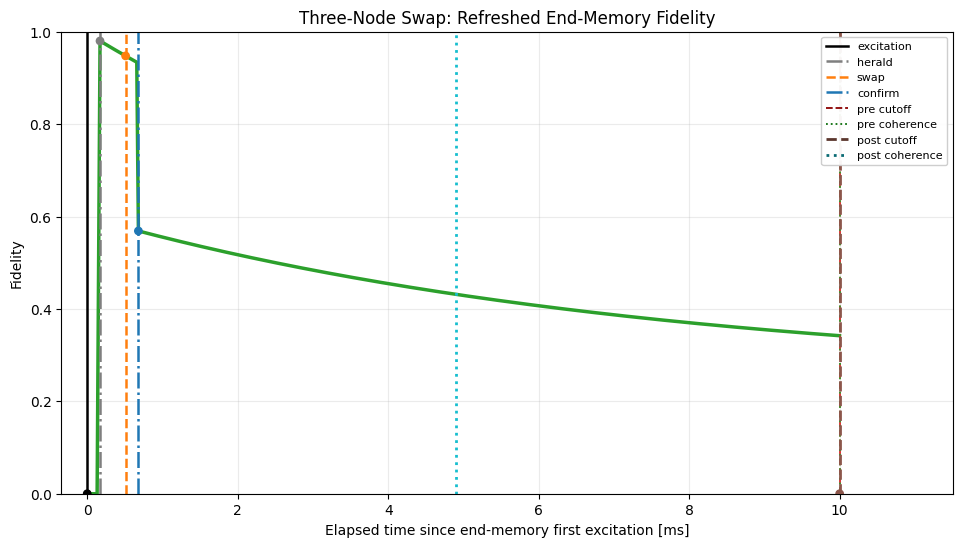

{'seed_used': 100,
 'tries_used': 1,
 'pre_cutoff_ms': 10.0,
 'post_cutoff_ms': 10.0,
 'pre_coherence_ms': 10.0,
 'post_coherence_ms': 4.9000125}

In [12]:
symmetric_left = ElementaryLinkConfig(
    label="left",
    distance_m=32_000,
    attenuation_db_per_m=0.0002,
    coherence_time_s=0.01,
    cutoff_ratio=1,
    bsm_success_rate=0.99,
    raw_fidelity=0.98,
    raw_epr_errors=[1/3, 1/3, 1/3],
    detector_efficiency=0.95,
    detector_count_rate=5e7,
    detector_resolution_ps=150,
    fiber_spec=base_spec,
)

symmetric_right = ElementaryLinkConfig(
    label="right",
    distance_m=18_000,
    attenuation_db_per_m=0.0002,
    coherence_time_s=0.01,
    cutoff_ratio=1,
    bsm_success_rate=0.99,
    raw_fidelity=0.98,
    raw_epr_errors=[1/3, 1/3, 1/3],
    detector_efficiency=0.95,
    detector_count_rate=5e7,
    detector_resolution_ps=150,
    fiber_spec=base_spec,
)

symmetric_swap = SwapCalibration(success_prob=1.0, degradation=1)

symmetric_trace = collect_three_node_swap_time_trace(
    symmetric_left,
    symmetric_right,
    symmetric_swap,
    seed=100,
    stop_time_s=1,
    sample_points=240,
    max_seed_tries=40,
)

if not symmetric_trace["success"]:
    raise RuntimeError("No successful symmetric three-node swap trace was found.")

symmetric_times_ms = np.array(symmetric_trace["elapsed_times_s"]) * 1e3
symmetric_after_trace = np.array(symmetric_trace["after_trace"], dtype=float)
symmetric_herald_ms = symmetric_trace["herald_time_s"] * 1e3
symmetric_swap_ms = symmetric_trace["swap_time_s"] * 1e3
symmetric_confirm_ms = symmetric_trace["confirm_time_s"] * 1e3
symmetric_pre_cutoff_ms = symmetric_trace["pre_swap_cutoff_time_s"] * 1e3
symmetric_pre_coherence_ms = symmetric_trace["pre_swap_coherence_time_s"] * 1e3
symmetric_post_cutoff_ms = symmetric_trace["post_swap_cutoff_time_s"] * 1e3
symmetric_post_coherence_ms = symmetric_trace["post_swap_coherence_time_s"] * 1e3
symmetric_xmax_ms = max(float(symmetric_times_ms.max()), symmetric_pre_coherence_ms * 1.15, symmetric_post_coherence_ms * 1.15)
symmetric_xmin_ms = -0.03 * symmetric_xmax_ms

fig, ax = plt.subplots(figsize=(11.5, 6.0))
ax.plot(symmetric_times_ms, symmetric_after_trace, color="#2ca02c", linewidth=2.5)
for x, line_color, style, width in [
    (0.0, "#000000", "-", 1.8),
    (symmetric_herald_ms, "#7f7f7f", "-.", 1.8),
    (symmetric_swap_ms, "#ff7f0e", "--", 1.8),
    (symmetric_confirm_ms, "#1f77b4", "-.", 1.8),
    (symmetric_pre_cutoff_ms, "#d62728", "--", 1.3),
    (symmetric_pre_coherence_ms, "#2ca02c", ":", 1.3),
    (symmetric_post_cutoff_ms, "#8c564b", "--", 2.0),
    (symmetric_post_coherence_ms, "#17becf", ":", 2.0),
]:
    ax.axvline(x, color=line_color, linestyle=style, linewidth=width)
ax.scatter(
    [0.0, symmetric_herald_ms, symmetric_swap_ms, symmetric_confirm_ms, symmetric_post_cutoff_ms],
    [float(np.interp(0.0, symmetric_times_ms, symmetric_after_trace)), float(np.interp(symmetric_herald_ms, symmetric_times_ms, symmetric_after_trace)), float(np.interp(symmetric_swap_ms, symmetric_times_ms, symmetric_after_trace)), float(symmetric_trace["refreshed_end_to_end_fidelity"]), 0.0],
    color=["#000000", "#7f7f7f", "#ff7f0e", "#1f77b4", "#8c564b"],
    zorder=4,
    s=28,
)
ax.set_title("Three-Node Swap: Refreshed End-Memory Fidelity")
ax.set_xlabel("Elapsed time since end-memory first excitation [ms]")
ax.set_ylabel("Fidelity")
ax.set_xlim(symmetric_xmin_ms, symmetric_xmax_ms)
ax.set_ylim(0, 1.0)
ax.grid(alpha=0.25)
sym_event_handles = [
    Line2D([0], [0], color="#000000", linestyle="-", linewidth=1.8, label="excitation"),
    Line2D([0], [0], color="#7f7f7f", linestyle="-.", linewidth=1.8, label="herald"),
    Line2D([0], [0], color="#ff7f0e", linestyle="--", linewidth=1.8, label="swap"),
    Line2D([0], [0], color="#1f77b4", linestyle="-.", linewidth=1.8, label="confirm"),
    Line2D([0], [0], color="#8b0000", linestyle="--", linewidth=1.3, label="pre cutoff"),
    Line2D([0], [0], color="#0b6e0b", linestyle=":", linewidth=1.3, label="pre coherence"),
    Line2D([0], [0], color="#5b362d", linestyle="--", linewidth=2.0, label="post cutoff"),
    Line2D([0], [0], color="#0b6b74", linestyle=":", linewidth=2.0, label="post coherence"),
]
ax.legend(handles=sym_event_handles, loc="upper right", fontsize=8, framealpha=0.95)
plt.show()

{
    "seed_used": symmetric_trace["seed_used"],
    "tries_used": symmetric_trace["tries_used"],
    "pre_cutoff_ms": symmetric_pre_cutoff_ms,
    "post_cutoff_ms": symmetric_post_cutoff_ms,
    "pre_coherence_ms": symmetric_pre_coherence_ms,
    "post_coherence_ms": symmetric_post_coherence_ms,
}


## Continuous Three-Node Rate Stabilization

This example runs one queueing model-style three-node topology in continuous operation for a fixed simulated time. The only stopping condition is the horizon. Every delivered end-to-end pair is consumed immediately, so the reservation keeps generating new pairs. The plot reports the cumulative delivered-pair rate at one-second checkpoints.


Topology: N1 == 32 km elementary link == N2 == 18 km elementary link == N3
Final mean throughput = 126.637 Hz
Mean delivered fidelity = 0.8537


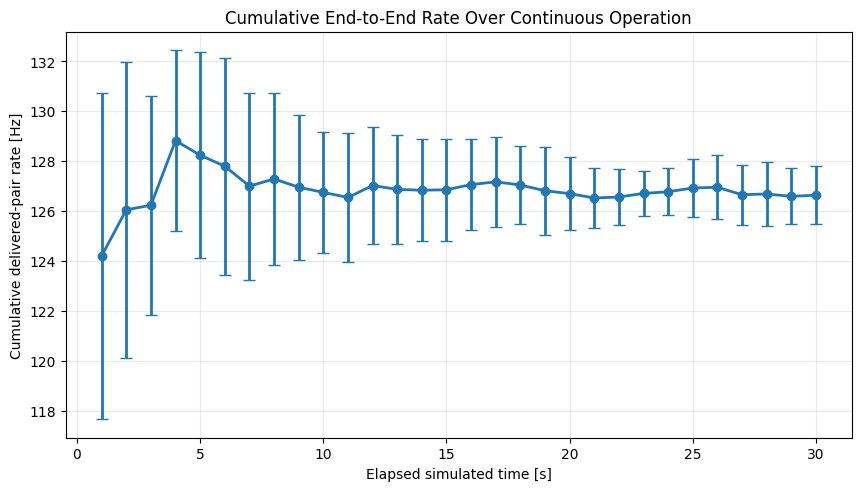

In [3]:
from dataclasses import replace

q_model_left = ElementaryLinkConfig(
    label="q-model left 32 km elementary link",
    distance_m=32_000,
    attenuation_db_per_m=0.0002,
    coherence_time_s=0.1,
    cutoff_ratio=1.0,
    local_coherence_time_s=0.2,
    remote_coherence_time_s=0.1,
    memory_decoherence_errors=[0, 0, 1],
    bsm_success_rate=0.99,
    raw_fidelity=0.93875,
    raw_epr_errors=[0.20408163265306123, 0.20408163265306123, 0.5918367346938775],
    detector_efficiency=0.95,
    detector_count_rate=5e7,
    detector_resolution_ps=150,
    fiber_spec=base_spec,
)

q_model_right = ElementaryLinkConfig(
    label="q-model right 18 km elementary link",
    distance_m=18_000,
    attenuation_db_per_m=0.0002,
    coherence_time_s=0.1,
    cutoff_ratio=1.0,
    local_coherence_time_s=0.1,
    remote_coherence_time_s=0.1,
    memory_decoherence_errors=[0, 0, 1],
    bsm_success_rate=0.99,
    raw_fidelity=0.950625,
    raw_epr_errors=[0.2531645569620254, 0.2531645569620254, 0.4936708860759492],
    detector_efficiency=0.95,
    detector_count_rate=5e7,
    detector_resolution_ps=150,
    fiber_spec=base_spec,
)

q_model_swap = SwapCalibration(success_prob=0.5, degradation=1.0)
q_model_policy = FixedGeneratedLifetimePolicy()
rate_horizon_s = 30.0

rate_over_time = collect_three_node_rate_over_time(
    q_model_left,
    q_model_right,
    q_model_swap,
    num_runs=10,
    base_seed=91_000,
    horizon_s=rate_horizon_s,
    sample_period_s=1.0,
    target_fidelity=0.5,
    lifetime_policy=q_model_policy,
)

trace = rate_over_time["rate_trace_summary"]
print("Topology: N1 == 32 km elementary link == N2 == 18 km elementary link == N3")
print(f"Final mean throughput = {rate_over_time['summary']['throughput_hz']['mean']:.3f} Hz")
print(f"Mean delivered fidelity = {rate_over_time['summary']['fidelity_mean']['mean']:.4f}")

fig, ax = plt.subplots(figsize=(8.5, 4.8), constrained_layout=True)
ax.errorbar(
    trace["times_s"],
    trace["mean_rates_hz"],
    yerr=trace["std_rates_hz"],
    marker="o",
    capsize=4,
    linewidth=2,
)
ax.set_title("Cumulative End-to-End Rate Over Continuous Operation")
ax.set_xlabel("Elapsed simulated time [s]")
ax.set_ylabel("Cumulative delivered-pair rate [Hz]")
ax.grid(alpha=0.25)
plt.show()


## Continuous Rate Stabilization With Memory Allocation 3:3

This repeats the cumulative-rate view for the memory-allocation simulator with three left-link memories and three right-link memories. The plotted rate is based on all end-to-end pairs reported at the end node, not only pairs above the requested-fidelity threshold.


Memory allocation topology: N1 == 32 km elementary link == N2 == 18 km elementary link == N3
Allocation = 3:3, multiplexing=True
TTL left/right = 5.755 / 4.316 ms
Final mean throughput = 288.983 Hz
Mean delivered fidelity = 0.8711
Reported deliveries = 86695; above F_req = 33290; below F_req = 53405


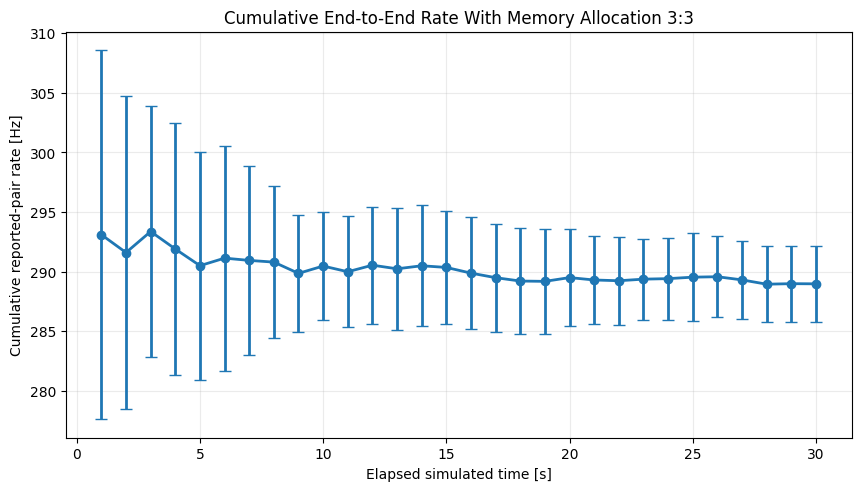

In [4]:
allocation_rate_config = AllocationQueueConfig(
    left_distance_km=32.0,
    right_distance_km=18.0,
    left_raw_fidelity=0.93875,
    right_raw_fidelity=0.950625,
    swap_success_prob=0.5,
    coherence_time_s=0.1,
)
allocation_rate_target_fidelity = 0.875
allocation_rate_horizon_s = 30.0
allocation_rate_sample_period_s = 1.0
allocation_rate_num_runs = 10
allocation_rate_left_capacity = 3
allocation_rate_right_capacity = 3
allocation_rate_multiplexing = True

allocation_left_ttl_s, allocation_right_ttl_s = reference_ttls_for_required_fidelity(
    allocation_rate_config,
    allocation_rate_target_fidelity,
)
allocation_rate_trials = []
for run_idx in range(allocation_rate_num_runs):
    allocation_rate_trials.append(
        run_memory_allocation_sequence_trial(
            allocation_rate_config,
            left_capacity=allocation_rate_left_capacity,
            right_capacity=allocation_rate_right_capacity,
            left_ttl_s=allocation_left_ttl_s,
            right_ttl_s=allocation_right_ttl_s,
            target_fidelity=allocation_rate_target_fidelity,
            multiplexing=allocation_rate_multiplexing,
            horizon_s=allocation_rate_horizon_s,
            seed=960_000 + run_idx,
        )
    )

allocation_rate_times_s = np.arange(
    allocation_rate_sample_period_s,
    allocation_rate_horizon_s + 0.5 * allocation_rate_sample_period_s,
    allocation_rate_sample_period_s,
)
allocation_rate_traces = []
for trial in allocation_rate_trials:
    delivery_times = np.array(trial['delivery_times_s'], dtype=float)
    allocation_rate_traces.append([np.count_nonzero(delivery_times <= t) / t for t in allocation_rate_times_s])
allocation_rate_traces = np.array(allocation_rate_traces, dtype=float)
allocation_rate_mean = allocation_rate_traces.mean(axis=0)
allocation_rate_std = allocation_rate_traces.std(axis=0, ddof=1) if allocation_rate_num_runs > 1 else np.zeros_like(allocation_rate_mean)

allocation_final_rates = [trial['throughput_hz'] for trial in allocation_rate_trials]
allocation_final_fidelities = [trial['fidelity_mean'] for trial in allocation_rate_trials if not np.isnan(trial['fidelity_mean'])]
allocation_reported = sum(trial['pair_count'] for trial in allocation_rate_trials)
allocation_above_target = sum(trial['accepted_pair_count'] for trial in allocation_rate_trials)

print("Memory allocation topology: N1 == 32 km elementary link == N2 == 18 km elementary link == N3")
print(f"Allocation = {allocation_rate_left_capacity}:{allocation_rate_right_capacity}, multiplexing={allocation_rate_multiplexing}")
print(f"TTL left/right = {allocation_left_ttl_s * 1e3:.3f} / {allocation_right_ttl_s * 1e3:.3f} ms")
print(f"Final mean throughput = {np.mean(allocation_final_rates):.3f} Hz")
print(f"Mean delivered fidelity = {np.mean(allocation_final_fidelities):.4f}")
print(f"Reported deliveries = {allocation_reported}; above F_req = {allocation_above_target}; below F_req = {allocation_reported - allocation_above_target}")

fig, ax = plt.subplots(figsize=(8.5, 4.8), constrained_layout=True)
ax.errorbar(
    allocation_rate_times_s,
    allocation_rate_mean,
    yerr=allocation_rate_std,
    marker="o",
    capsize=4,
    linewidth=2,
)
ax.set_title("Cumulative End-to-End Rate With Memory Allocation 3:3")
ax.set_xlabel("Elapsed simulated time [s]")
ax.set_ylabel("Cumulative reported-pair rate [Hz]")
ax.grid(alpha=0.25)
plt.show()


## Elementary-Link Waiting-Time Histograms Before Swap

These histograms show how long the left and right elementary links waited before the middle-node swap executed. The first row uses only the physical coherence/cutoff behavior. The second row adds a 5 ms generated-pair TTL on both elementary links, so successful swap inputs should not wait longer than that TTL except for event-ordering granularity.


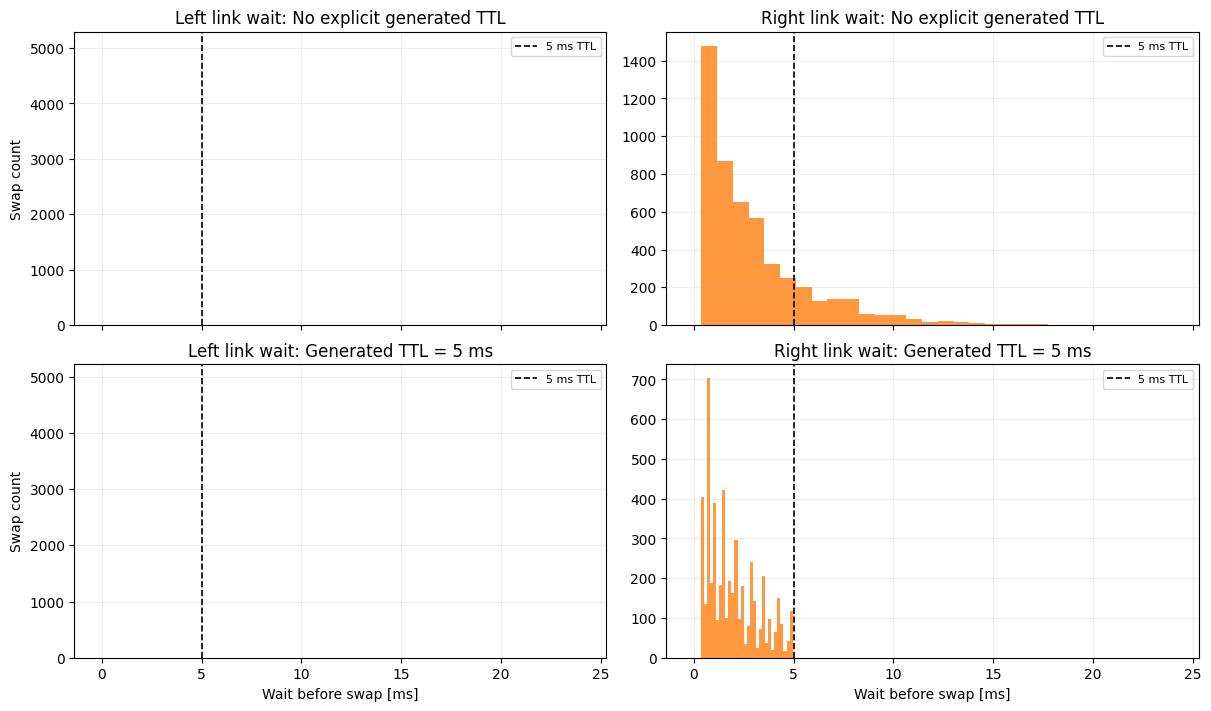

No TTL swaps sampled: 5042
With 5 ms TTL swaps sampled: 4972


In [6]:
hist_horizon_s = 10.0
hist_num_runs = 4
ttl_s = 0.005

waiting_no_ttl = collect_three_node_swap_waiting_histogram(
    q_model_left,
    q_model_right,
    q_model_swap,
    num_runs=hist_num_runs,
    base_seed=92_000,
    horizon_s=hist_horizon_s,
    target_fidelity=0.5,
    lifetime_policy=q_model_policy,
)

waiting_with_ttl = collect_three_node_swap_waiting_histogram(
    replace(q_model_left, generated_keepalive_s=ttl_s),
    replace(q_model_right, generated_keepalive_s=ttl_s),
    q_model_swap,
    num_runs=hist_num_runs,
    base_seed=93_000,
    horizon_s=hist_horizon_s,
    target_fidelity=0.5,
    lifetime_policy=q_model_policy,
)

fig, axes = plt.subplots(2, 2, figsize=(12, 7), constrained_layout=True, sharex=True)
configs = [
    (waiting_no_ttl, "No explicit generated TTL"),
    (waiting_with_ttl, "Generated TTL = 5 ms"),
]
for row_idx, (data, title) in enumerate(configs):
    left_wait_ms = np.array(data["left_wait_times_s"]) * 1e3
    right_wait_ms = np.array(data["right_wait_times_s"]) * 1e3
    axes[row_idx, 0].hist(left_wait_ms, bins=30, color="tab:blue", alpha=0.8)
    axes[row_idx, 1].hist(right_wait_ms, bins=30, color="tab:orange", alpha=0.8)
    axes[row_idx, 0].set_ylabel("Swap count")
    axes[row_idx, 0].set_title(f"Left link wait: {title}")
    axes[row_idx, 1].set_title(f"Right link wait: {title}")
    for ax in axes[row_idx]:
        ax.axvline(ttl_s * 1e3, color="black", linestyle="--", linewidth=1.2, label="5 ms TTL")
        ax.grid(alpha=0.2)
        ax.legend(fontsize=8)
axes[1, 0].set_xlabel("Wait before swap [ms]")
axes[1, 1].set_xlabel("Wait before swap [ms]")
plt.show()

print(f"No TTL swaps sampled: {len(waiting_no_ttl['left_wait_times_s'])}")
print(f"With 5 ms TTL swaps sampled: {len(waiting_with_ttl['left_wait_times_s'])}")


## Three-Node TTL Trade-Off Across The Two Elementary Links

This section keeps the same symmetric three-node setup, but now assigns an explicit TTL to each elementary link after entanglement generation. The TTL is the maximum extra waiting time that the external policy allows before the pair is discarded and the memory is reused.

The heatmaps below fix one requested end-to-end target fidelity and sweep the left-link and right-link TTLs independently. This shows how per-link ttl choices affect sustained throughput and the mean delivered end-to-end fidelity.


Symmetric ttl heatmap topology
N1 ======= N2 ======= N3
left link : distance=40.0 km | raw fidelity=0.980 | pauli=[0.3333333333333333, 0.3333333333333333, 0.3333333333333333]
right link: distance=40.0 km | raw fidelity=0.980 | pauli=[0.3333333333333333, 0.3333333333333333, 0.3333333333333333]



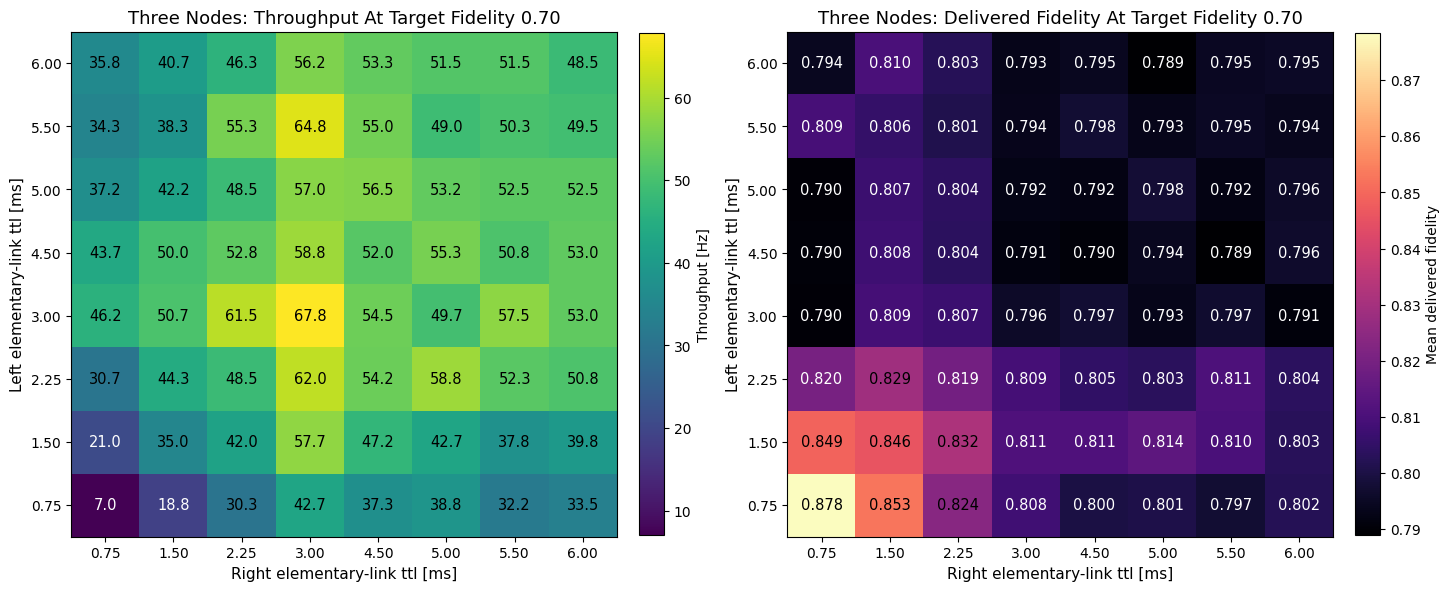

{'target_fidelity': 0.7,
 'left_ttl_ms': [0.75, 1.5, 2.25, 3.0, 4.5, 5.0, 5.5, 6.0],
 'right_ttl_ms': [0.75, 1.5, 2.25, 3.0, 4.5, 5.0, 5.5, 6.0],
 'throughput_heatmap': [[7.0,
   18.833333333333332,
   30.333333333333332,
   42.666666666666664,
   37.333333333333336,
   38.833333333333336,
   32.166666666666664,
   33.5],
  [21.0,
   35.0,
   42.0,
   57.666666666666664,
   47.166666666666664,
   42.666666666666664,
   37.833333333333336,
   39.833333333333336],
  [30.666666666666668,
   44.333333333333336,
   48.5,
   62.0,
   54.166666666666664,
   58.833333333333336,
   52.333333333333336,
   50.833333333333336],
  [46.166666666666664,
   50.666666666666664,
   61.5,
   67.83333333333333,
   54.5,
   49.666666666666664,
   57.5,
   53.0],
  [43.666666666666664,
   50.0,
   52.833333333333336,
   58.833333333333336,
   52.0,
   55.333333333333336,
   50.833333333333336,
   53.0],
  [37.166666666666664,
   42.166666666666664,
   48.5,
   57.0,
   56.5,
   53.166666666666664,
   52.5,


In [7]:
from dataclasses import replace

three_ttl_target_fidelity = 0.70
three_ttl_horizon_s = 1.0
three_ttl_grid_ms = np.array([0.75, 1.5, 2.25, 3.0, 4.5, 5.0, 5.5, 6.0], dtype=float)
three_ttl_policy = FixedGeneratedLifetimePolicy()

def print_topology(title, left_cfg, right_cfg):
    print(title)
    print("N1 ======= N2 ======= N3")
    print(f"left link : distance={left_cfg.distance_m/1000:.1f} km | raw fidelity={left_cfg.raw_fidelity:.3f} | pauli={left_cfg.raw_epr_errors}")
    print(f"right link: distance={right_cfg.distance_m/1000:.1f} km | raw fidelity={right_cfg.raw_fidelity:.3f} | pauli={right_cfg.raw_epr_errors}")
    print()

def build_ttl_heatmaps(left_base_cfg, right_base_cfg, base_seed):
    throughput = np.zeros((len(three_ttl_grid_ms), len(three_ttl_grid_ms)), dtype=float)
    delivered_fidelity = np.zeros_like(throughput)
    for row_idx, left_ttl_ms in enumerate(three_ttl_grid_ms):
        for col_idx, right_ttl_ms in enumerate(three_ttl_grid_ms):
            left_cfg = replace(left_base_cfg, generated_keepalive_s=left_ttl_ms * 1e-3)
            right_cfg = replace(right_base_cfg, generated_keepalive_s=right_ttl_ms * 1e-3)
            result = run_three_node_continuous_experiment(
                left_cfg,
                right_cfg,
                symmetric_swap,
                num_runs=6,
                base_seed=base_seed + row_idx * 1_000 + col_idx * 100,
                horizon_s=three_ttl_horizon_s,
                target_fidelity=three_ttl_target_fidelity,
                lifetime_policy=three_ttl_policy,
            )
            summary = result["summary"]
            throughput[row_idx, col_idx] = summary["throughput_hz"]["mean"]
            delivered_fidelity[row_idx, col_idx] = summary["fidelity_mean"]["mean"]
    return throughput, delivered_fidelity

def draw_ttl_heatmap(ax, data, title, cmap, value_fmt):
    im = ax.imshow(data, origin="lower", cmap=cmap, aspect="auto")
    ax.set_title(title, fontsize=13)
    ax.set_xlabel("Right elementary-link ttl [ms]", fontsize=11)
    ax.set_ylabel("Left elementary-link ttl [ms]", fontsize=11)
    ax.set_xticks(np.arange(len(three_ttl_grid_ms)), [f"{v:.2f}" for v in three_ttl_grid_ms])
    ax.set_yticks(np.arange(len(three_ttl_grid_ms)), [f"{v:.2f}" for v in three_ttl_grid_ms])
    ax.tick_params(axis="both", labelsize=10)
    norm = im.norm
    for r in range(data.shape[0]):
        for c in range(data.shape[1]):
            value = data[r, c]
            text_color = "black" if 0.38 < norm(value) else "white"
            ax.text(c, r, value_fmt.format(value), ha="center", va="center", color=text_color, fontsize=10.5)
    return im

print_topology("Symmetric ttl heatmap topology", symmetric_left, symmetric_right)
symmetric_throughput_heatmap, symmetric_fidelity_heatmap = build_ttl_heatmaps(symmetric_left, symmetric_right, 40_000)

fig, axes = plt.subplots(1, 2, figsize=(14.4, 5.8), constrained_layout=True)
im0 = draw_ttl_heatmap(axes[0], symmetric_throughput_heatmap, f"Three Nodes: Throughput At Target Fidelity {three_ttl_target_fidelity:.2f}", "viridis", "{:.1f}")
im1 = draw_ttl_heatmap(axes[1], symmetric_fidelity_heatmap, f"Three Nodes: Delivered Fidelity At Target Fidelity {three_ttl_target_fidelity:.2f}", "magma", "{:.3f}")
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04, label="Throughput [Hz]")
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04, label="Mean delivered fidelity")
plt.show()

symmetric_ttl_heatmap_summary = {
    "target_fidelity": three_ttl_target_fidelity,
    "left_ttl_ms": three_ttl_grid_ms.tolist(),
    "right_ttl_ms": three_ttl_grid_ms.tolist(),
    "throughput_heatmap": symmetric_throughput_heatmap.tolist(),
    "fidelity_heatmap": symmetric_fidelity_heatmap.tolist(),
}
symmetric_ttl_heatmap_summary


Symmetric ttl heatmap topology
N1 ======= N2 ======= N3
left link : distance=40.0 km | raw fidelity=0.980 | pauli=[0.3333333333333333, 0.3333333333333333, 0.3333333333333333]
right link: distance=40.0 km | raw fidelity=0.980 | pauli=[0.3333333333333333, 0.3333333333333333, 0.3333333333333333]



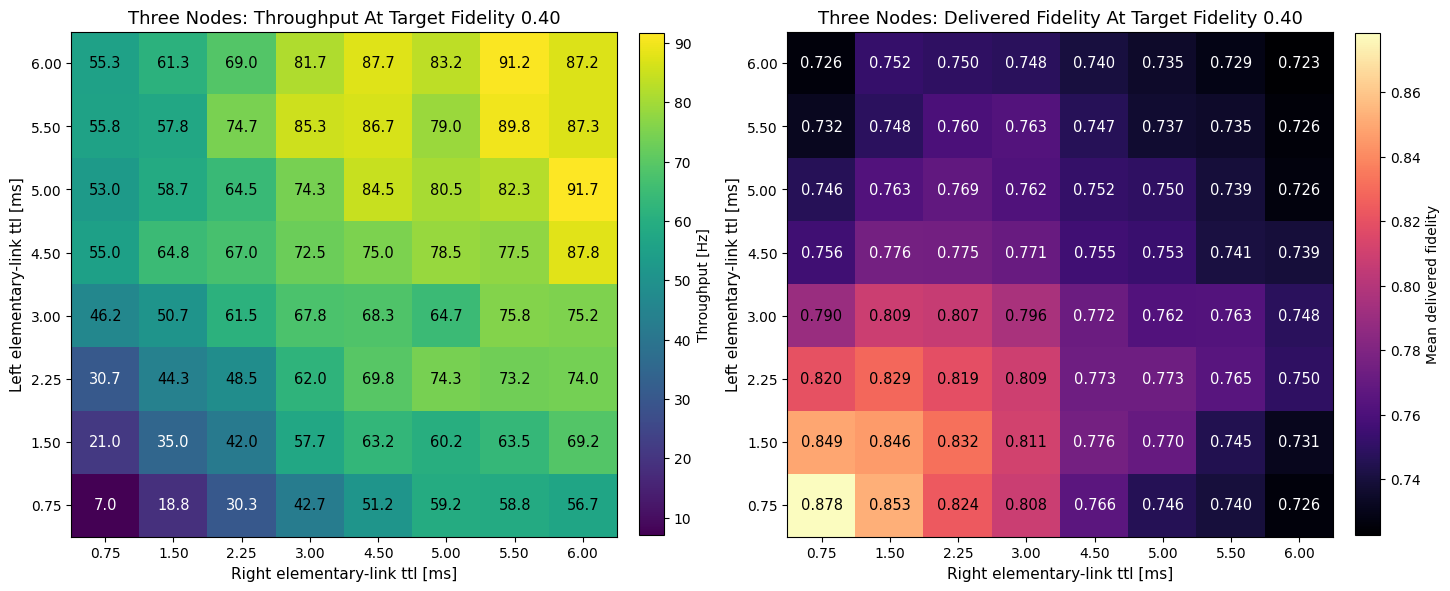

{'target_fidelity': 0.4,
 'left_ttl_ms': [0.75, 1.5, 2.25, 3.0, 4.5, 5.0, 5.5, 6.0],
 'right_ttl_ms': [0.75, 1.5, 2.25, 3.0, 4.5, 5.0, 5.5, 6.0],
 'throughput_heatmap': [[7.0,
   18.833333333333332,
   30.333333333333332,
   42.666666666666664,
   51.166666666666664,
   59.166666666666664,
   58.833333333333336,
   56.666666666666664],
  [21.0,
   35.0,
   42.0,
   57.666666666666664,
   63.166666666666664,
   60.166666666666664,
   63.5,
   69.16666666666667],
  [30.666666666666668,
   44.333333333333336,
   48.5,
   62.0,
   69.83333333333333,
   74.33333333333333,
   73.16666666666667,
   74.0],
  [46.166666666666664,
   50.666666666666664,
   61.5,
   67.83333333333333,
   68.33333333333333,
   64.66666666666667,
   75.83333333333333,
   75.16666666666667],
  [55.0, 64.83333333333333, 67.0, 72.5, 75.0, 78.5, 77.5, 87.83333333333333],
  [53.0,
   58.666666666666664,
   64.5,
   74.33333333333333,
   84.5,
   80.5,
   82.33333333333333,
   91.66666666666667],
  [55.833333333333336,
 

In [8]:
from dataclasses import replace

three_ttl_target_fidelity = 0.4
three_ttl_horizon_s = 1.0
three_ttl_grid_ms = np.array([0.75, 1.5, 2.25, 3.0, 4.5, 5.0, 5.5, 6.0], dtype=float)
three_ttl_policy = FixedGeneratedLifetimePolicy()

def print_topology(title, left_cfg, right_cfg):
    print(title)
    print("N1 ======= N2 ======= N3")
    print(f"left link : distance={left_cfg.distance_m/1000:.1f} km | raw fidelity={left_cfg.raw_fidelity:.3f} | pauli={left_cfg.raw_epr_errors}")
    print(f"right link: distance={right_cfg.distance_m/1000:.1f} km | raw fidelity={right_cfg.raw_fidelity:.3f} | pauli={right_cfg.raw_epr_errors}")
    print()

def build_ttl_heatmaps(left_base_cfg, right_base_cfg, base_seed):
    throughput = np.zeros((len(three_ttl_grid_ms), len(three_ttl_grid_ms)), dtype=float)
    delivered_fidelity = np.zeros_like(throughput)
    for row_idx, left_ttl_ms in enumerate(three_ttl_grid_ms):
        for col_idx, right_ttl_ms in enumerate(three_ttl_grid_ms):
            left_cfg = replace(left_base_cfg, generated_keepalive_s=left_ttl_ms * 1e-3)
            right_cfg = replace(right_base_cfg, generated_keepalive_s=right_ttl_ms * 1e-3)
            result = run_three_node_continuous_experiment(
                left_cfg,
                right_cfg,
                symmetric_swap,
                num_runs=6,
                base_seed=base_seed + row_idx * 1_000 + col_idx * 100,
                horizon_s=three_ttl_horizon_s,
                target_fidelity=three_ttl_target_fidelity,
                lifetime_policy=three_ttl_policy,
            )
            summary = result["summary"]
            throughput[row_idx, col_idx] = summary["throughput_hz"]["mean"]
            delivered_fidelity[row_idx, col_idx] = summary["fidelity_mean"]["mean"]
    return throughput, delivered_fidelity

def draw_ttl_heatmap(ax, data, title, cmap, value_fmt):
    im = ax.imshow(data, origin="lower", cmap=cmap, aspect="auto")
    ax.set_title(title, fontsize=13)
    ax.set_xlabel("Right elementary-link ttl [ms]", fontsize=11)
    ax.set_ylabel("Left elementary-link ttl [ms]", fontsize=11)
    ax.set_xticks(np.arange(len(three_ttl_grid_ms)), [f"{v:.2f}" for v in three_ttl_grid_ms])
    ax.set_yticks(np.arange(len(three_ttl_grid_ms)), [f"{v:.2f}" for v in three_ttl_grid_ms])
    ax.tick_params(axis="both", labelsize=10)
    norm = im.norm
    for r in range(data.shape[0]):
        for c in range(data.shape[1]):
            value = data[r, c]
            text_color = "black" if 0.38 < norm(value) else "white"
            ax.text(c, r, value_fmt.format(value), ha="center", va="center", color=text_color, fontsize=10.5)
    return im

print_topology("Symmetric ttl heatmap topology", symmetric_left, symmetric_right)
symmetric_throughput_heatmap, symmetric_fidelity_heatmap = build_ttl_heatmaps(symmetric_left, symmetric_right, 40_000)

fig, axes = plt.subplots(1, 2, figsize=(14.4, 5.8), constrained_layout=True)
im0 = draw_ttl_heatmap(axes[0], symmetric_throughput_heatmap, f"Three Nodes: Throughput At Target Fidelity {three_ttl_target_fidelity:.2f}", "viridis", "{:.1f}")
im1 = draw_ttl_heatmap(axes[1], symmetric_fidelity_heatmap, f"Three Nodes: Delivered Fidelity At Target Fidelity {three_ttl_target_fidelity:.2f}", "magma", "{:.3f}")
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04, label="Throughput [Hz]")
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04, label="Mean delivered fidelity")
plt.show()

symmetric_ttl_heatmap_summary = {
    "target_fidelity": three_ttl_target_fidelity,
    "left_ttl_ms": three_ttl_grid_ms.tolist(),
    "right_ttl_ms": three_ttl_grid_ms.tolist(),
    "throughput_heatmap": symmetric_throughput_heatmap.tolist(),
    "fidelity_heatmap": symmetric_fidelity_heatmap.tolist(),
}
symmetric_ttl_heatmap_summary

## Three-Node TTL Trade-Off With Non-Equivalent Elementary Links

This second ttl study uses the same three-node topology shape, but now the two elementary links are not equivalent. The right link starts with a lower raw fidelity than the left one, so the heatmaps show how asymmetric link quality changes the ttl trade-off.


Asymmetric ttl heatmap topology
N1 ======= N2 ======= N3
left link : distance=40.0 km | raw fidelity=0.980 | pauli=[0.3333333333333333, 0.3333333333333333, 0.3333333333333333]
right link: distance=40.0 km | raw fidelity=0.900 | pauli=[0.3333333333333333, 0.3333333333333333, 0.3333333333333333]



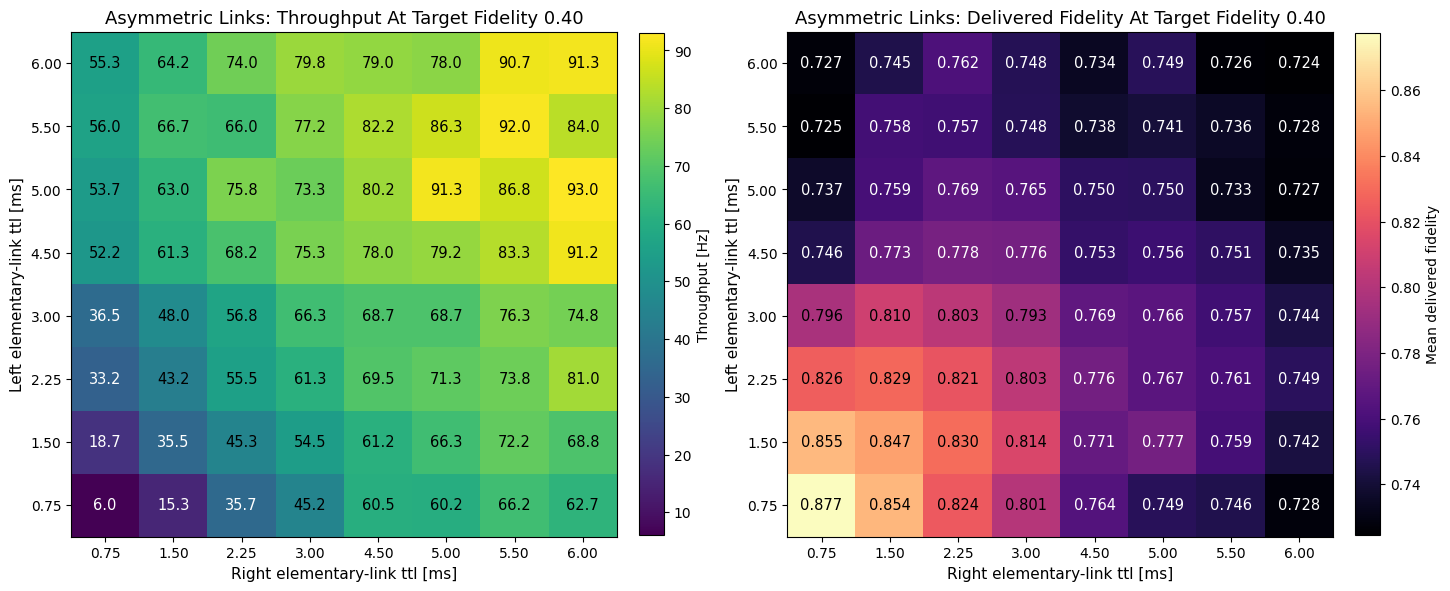

{'target_fidelity': 0.4,
 'left_ttl_ms': [0.75, 1.5, 2.25, 3.0, 4.5, 5.0, 5.5, 6.0],
 'right_ttl_ms': [0.75, 1.5, 2.25, 3.0, 4.5, 5.0, 5.5, 6.0],
 'throughput_heatmap': [[6.0,
   15.333333333333334,
   35.666666666666664,
   45.166666666666664,
   60.5,
   60.166666666666664,
   66.16666666666667,
   62.666666666666664],
  [18.666666666666668,
   35.5,
   45.333333333333336,
   54.5,
   61.166666666666664,
   66.33333333333333,
   72.16666666666667,
   68.83333333333333],
  [33.166666666666664,
   43.166666666666664,
   55.5,
   61.333333333333336,
   69.5,
   71.33333333333333,
   73.83333333333333,
   81.0],
  [36.5,
   48.0,
   56.833333333333336,
   66.33333333333333,
   68.66666666666667,
   68.66666666666667,
   76.33333333333333,
   74.83333333333333],
  [52.166666666666664,
   61.333333333333336,
   68.16666666666667,
   75.33333333333333,
   78.0,
   79.16666666666667,
   83.33333333333333,
   91.16666666666667],
  [53.666666666666664,
   63.0,
   75.83333333333333,
   73.3333

In [9]:
asymmetric_left = replace(
    symmetric_left,
    label="asymmetric left",
    raw_fidelity=0.98,
    raw_epr_errors=[1/3, 1/3, 1/3],
)

asymmetric_right = replace(
    symmetric_right,
    label="asymmetric right",
    raw_fidelity=0.90,
    raw_epr_errors=[1/3, 1/3, 1/3],
)

print_topology("Asymmetric ttl heatmap topology", asymmetric_left, asymmetric_right)
asymmetric_throughput_heatmap, asymmetric_fidelity_heatmap = build_ttl_heatmaps(asymmetric_left, asymmetric_right, 52_000)

fig, axes = plt.subplots(1, 2, figsize=(14.4, 5.8), constrained_layout=True)
im0 = draw_ttl_heatmap(axes[0], asymmetric_throughput_heatmap, f"Asymmetric Links: Throughput At Target Fidelity {three_ttl_target_fidelity:.2f}", "viridis", "{:.1f}")
im1 = draw_ttl_heatmap(axes[1], asymmetric_fidelity_heatmap, f"Asymmetric Links: Delivered Fidelity At Target Fidelity {three_ttl_target_fidelity:.2f}", "magma", "{:.3f}")
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04, label="Throughput [Hz]")
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04, label="Mean delivered fidelity")
plt.show()

asymmetric_ttl_heatmap_summary = {
    "target_fidelity": three_ttl_target_fidelity,
    "left_ttl_ms": three_ttl_grid_ms.tolist(),
    "right_ttl_ms": three_ttl_grid_ms.tolist(),
    "throughput_heatmap": asymmetric_throughput_heatmap.tolist(),
    "fidelity_heatmap": asymmetric_fidelity_heatmap.tolist(),
}
asymmetric_ttl_heatmap_summary


## Three-Node Throughput, Fidelity, And Latency Versus Requested Minimum Fidelity

These sweeps use the same symmetric three-node setup as the trace above, but now in continuous operation over fixed simulation-time horizons. Each accepted end-to-end pair is consumed immediately so the reservation can keep regenerating new pairs.

For these continuous sweeps:
- throughput = delivered end-to-end pairs divided by the configured horizon
- final fidelity = mean fidelity of the delivered end-to-end pairs
- latency = mean interval between delivered end-to-end pairs, with the first interval measured from reservation start to the first delivery


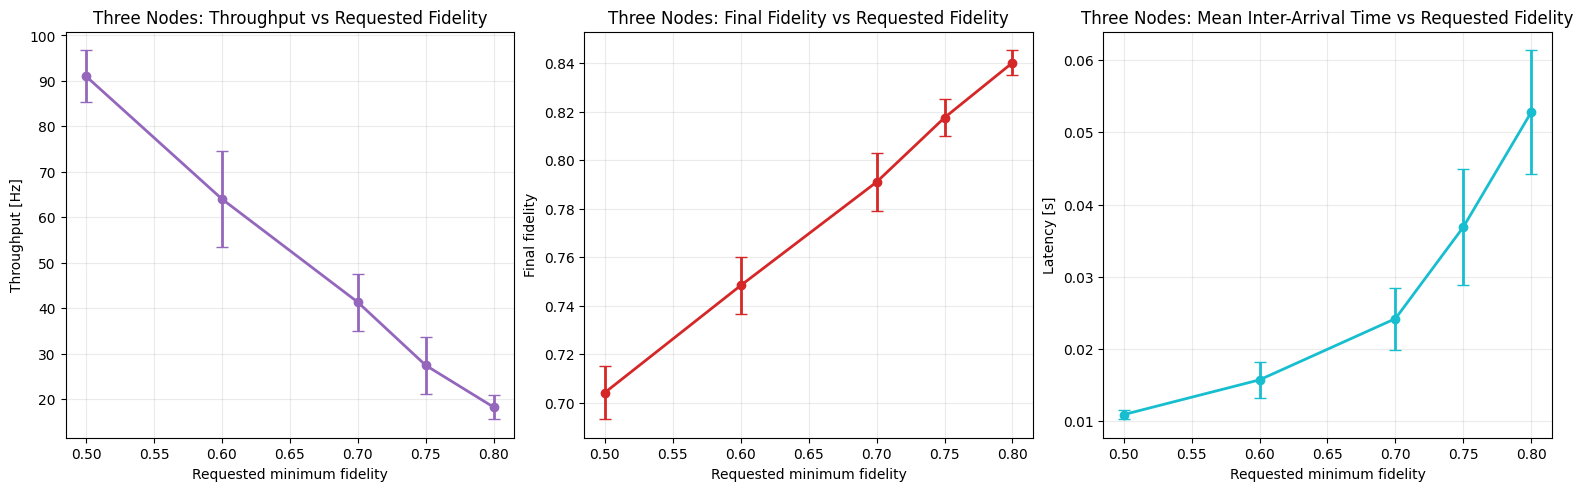

[{'target_fidelity': 0.5,
  'throughput_mean': 91.0,
  'throughput_std': 5.754225500544023,
  'fidelity_mean': 0.7041274137041591,
  'fidelity_std': 0.010984719173446388,
  'latency_mean_s': 0.010928090777401906,
  'latency_std_s': 0.000644252548172774,
  'pair_count_mean': 91,
  'pair_count_std': 5.754225500544023},
 {'target_fidelity': 0.6,
  'throughput_mean': 64.0,
  'throughput_std': 10.488088481701515,
  'fidelity_mean': 0.7482869071025534,
  'fidelity_std': 0.011560030486680927,
  'latency_mean_s': 0.015737228328962353,
  'latency_std_s': 0.0024498688731982585,
  'pair_count_mean': 64,
  'pair_count_std': 10.488088481701515},
 {'target_fidelity': 0.7,
  'throughput_mean': 41.3,
  'throughput_std': 6.290204024248074,
  'fidelity_mean': 0.7909275689710746,
  'fidelity_std': 0.012097143278475716,
  'latency_mean_s': 0.024209685925043273,
  'latency_std_s': 0.0042817550395303,
  'pair_count_mean': 41.3,
  'pair_count_std': 6.290204024248074},
 {'target_fidelity': 0.75,
  'throughput

In [10]:
three_threshold_grid = [0.50, 0.60, 0.70, 0.75, 0.80]
three_horizon_s = 1.0

three_threshold_rows = sweep_three_node_target_fidelity_continuous(
    symmetric_left,
    symmetric_right,
    symmetric_swap,
    three_threshold_grid,
    num_runs=10,
    base_seed=30_000,
    horizon_s=three_horizon_s,
)

fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.8), constrained_layout=True)

def plot_threshold_panel(ax, rows, metric_key, metric_err_key, color, title, ylabel):
    x = np.array([row["target_fidelity"] for row in rows], dtype=float)
    y = np.array([row[metric_key] for row in rows], dtype=float)
    yerr = np.array([row[metric_err_key] for row in rows], dtype=float)
    ax.errorbar(x, y, yerr=yerr, color=color, marker="o", linewidth=2, capsize=4)
    ax.set_title(title)
    ax.set_xlabel("Requested minimum fidelity")
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.25)

plot_threshold_panel(axes[0], three_threshold_rows, "throughput_mean", "throughput_std", "#9467bd", "Three Nodes: Throughput vs Requested Fidelity", "Throughput [Hz]")
plot_threshold_panel(axes[1], three_threshold_rows, "fidelity_mean", "fidelity_std", "#d62728", "Three Nodes: Final Fidelity vs Requested Fidelity", "Final fidelity")
plot_threshold_panel(axes[2], three_threshold_rows, "latency_mean_s", "latency_std_s", "#17becf", "Three Nodes: Mean Inter-Arrival Time vs Requested Fidelity", "Latency [s]")
plt.show()

three_threshold_rows


## Three-Node Cutoff-Ratio Trade-Off Under A Fidelity Request

These sweeps keep the same symmetric three-node setup and the same continuous-operation model. Each delivered pair is consumed immediately, so the network keeps trying to regenerate new end-to-end entanglement over the fixed horizon.

The last panel shows the sustained rate-versus-quality trade-off directly.


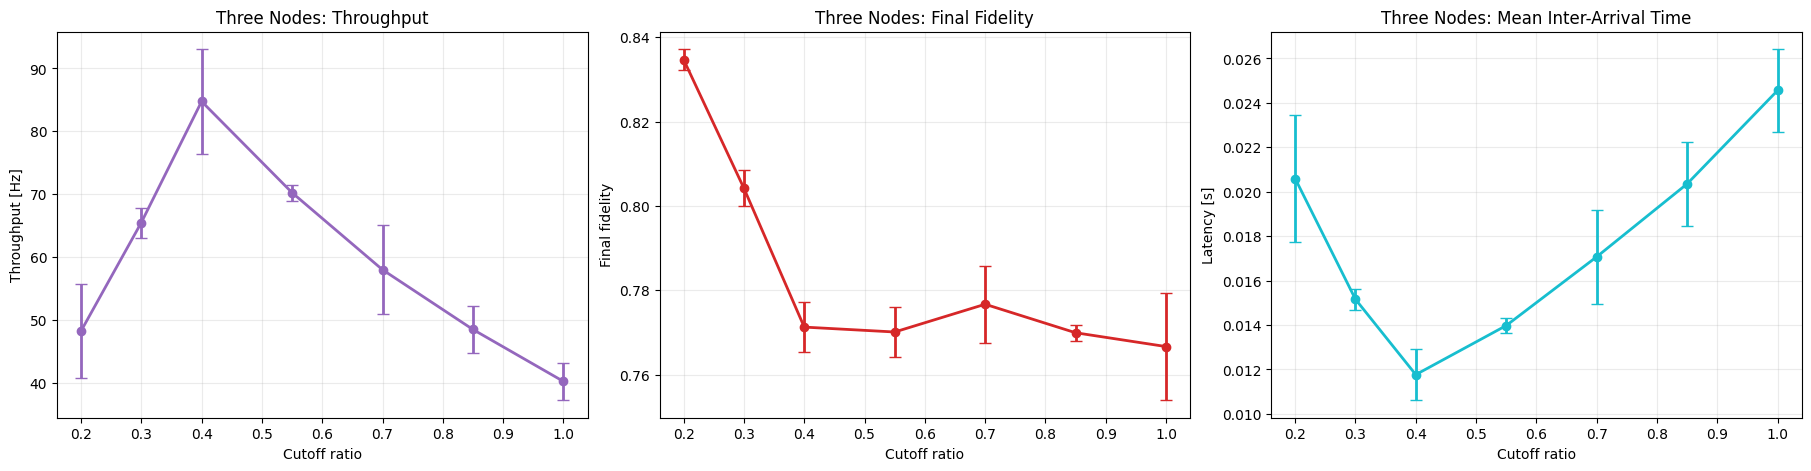

[{'cutoff_ratio': 0.2,
  'target_fidelity': 0.65,
  'throughput_mean': 48.25,
  'throughput_std': 7.41057802513857,
  'fidelity_mean': 0.834684217433754,
  'fidelity_std': 0.0024805036703193016,
  'latency_mean_s': 0.02058941492463176,
  'latency_std_s': 0.0028705300811725756,
  'pair_count_mean': 48.25,
  'pair_count_std': 7.41057802513857},
 {'cutoff_ratio': 0.3,
  'target_fidelity': 0.65,
  'throughput_mean': 65.5,
  'throughput_std': 2.3804761428476167,
  'fidelity_mean': 0.80416720705717,
  'fidelity_std': 0.004239200111468401,
  'latency_mean_s': 0.015154435299042571,
  'latency_std_s': 0.0004708019518789282,
  'pair_count_mean': 65.5,
  'pair_count_std': 2.3804761428476167},
 {'cutoff_ratio': 0.4,
  'target_fidelity': 0.65,
  'throughput_mean': 84.75,
  'throughput_std': 8.301606270274847,
  'fidelity_mean': 0.7712595231833526,
  'fidelity_std': 0.005860328392754545,
  'latency_mean_s': 0.011762276937040024,
  'latency_std_s': 0.0011491115013288887,
  'pair_count_mean': 84.75,
 

In [11]:
three_cutoff_grid = [0.2, 0.3, 0.40, 0.55, 0.70, 0.85, 1.00]
three_cutoff_target = 0.65

three_cutoff_rows = sweep_three_node_cutoff_ratio_continuous(
    symmetric_left,
    symmetric_right,
    symmetric_swap,
    three_cutoff_grid,
    target_fidelity=three_cutoff_target,
    num_runs=4,
    base_seed=34_000,
    horizon_s=three_horizon_s,
)

fig, axes = plt.subplots(1, 3, figsize=(18, 4.6), constrained_layout=True)

def plot_cutoff_panel(ax, rows, y_key, yerr_key, color, title, ylabel):
    x = np.array([row["cutoff_ratio"] for row in rows], dtype=float)
    y = np.array([row[y_key] for row in rows], dtype=float)
    yerr = np.array([row[yerr_key] for row in rows], dtype=float)
    ax.errorbar(x, y, yerr=yerr, color=color, marker="o", linewidth=2, capsize=4)
    ax.set_title(title)
    ax.set_xlabel("Cutoff ratio")
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.25)

plot_cutoff_panel(axes[0], three_cutoff_rows, "throughput_mean", "throughput_std", "#9467bd", "Three Nodes: Throughput", "Throughput [Hz]")
plot_cutoff_panel(axes[1], three_cutoff_rows, "fidelity_mean", "fidelity_std", "#d62728", "Three Nodes: Final Fidelity", "Final fidelity")
plot_cutoff_panel(axes[2], three_cutoff_rows, "latency_mean_s", "latency_std_s", "#17becf", "Three Nodes: Mean Inter-Arrival Time", "Latency [s]")
#spread_x = np.array([row["cutoff_ratio"] for row in three_cutoff_rows], dtype=float)
#spread_mean = np.array([row["fidelity_mean"] for row in three_cutoff_rows], dtype=float)
#spread_std = np.array([row["fidelity_std"] for row in three_cutoff_rows], dtype=float)
#axes[3].plot(spread_x, spread_mean, color="#7f7f7f", marker="o", linewidth=2)
#axes[3].fill_between(spread_x, spread_mean - spread_std, spread_mean + spread_std, color="#7f7f7f", alpha=0.18)
#for row in three_cutoff_rows:
#    axes[3].text(row["cutoff_ratio"], row["fidelity_mean"], f" r={row['cutoff_ratio']:.2f}", fontsize=8, ha="left", va="bottom")
#axes[3].set_title("Three Nodes: Delivery Fidelity Spread vs Cutoff Ratio")
#axes[3].set_xlabel("Cutoff ratio")
#axes[3].set_ylabel("Delivered fidelity")
#axes[3].grid(alpha=0.25)

plt.show()

three_cutoff_rows
